# **LEO Orbital Congestion Analysis**

## 1. Setup & Data Import
Loading the required Python libraries and ingesting the raw Union of Concerned Scientists (UCS) Satellite Database for analysis.

In [ ]:
import pandas as pd
df = pd.read_excel('UCS-Satellite-Database.xlsx')
df.head()

,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAt-4,AAt-4,Denmark,Denmark,University of Aalborg,Civil,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"ABS-2 (Koreasat-8, ST-3)",ABS-2,NR,Multinational,Asia Broadcast Satellite Ltd.,Commercial,Communications,NaN,GEO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Name of Satellite, Alternate Names', 'Current Official Name of Satellite', 'Country/Org of UN Registry', 'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose', 'Detailed Purpose', 'Class of Orbit', 'Type of Orbit', 'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)', 'Eccentricity', 'Inclination (degrees)', 'Period (minutes)', 'Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)', 'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor', 'Country of Contractor', 'Launch Site', 'Launch Vehicle', 'COSPAR Number', 'NORAD Number', 'Comments', 'Unnamed: 28', 'Source Used for Orbital Data', 'Source', 'Source.1', 'Source.2', 'Source.3', 'Source.4', 'Source.5', 'Source.6', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unname

## 2. Data Cleaning & Feature Engineering
The initial dataset contains some unused bibliography columns and empty columns, which are removed to optimize the dataframe.

Additionally, because satellite orbits are elliptical, using Perigee or Apogee alone does not accurately reflect the operating altitude. We calculate a `Mean Altitude` to get a reliable average altitude.

In [ ]:
df_clean = df.loc[:, ~df.columns.str.contains('Unnamed|Source')].copy()

df_leo = df_clean[df_clean['Class of Orbit'] == 'LEO'].copy()
df_leo['Mean Altitude (km)'] = (df_leo['Perigee (km)'] + df_leo['Apogee (km)']) / 2

print(f"\nOriginal dataset size: {df.shape[0]} objects")
print(f"Filtered LEO dataset size: {df_leo.shape[0]} objects")

cols_to_show = ['Current Official Name of Satellite', 'Operator/Owner', 'Mean Altitude (km)']
df_leo[cols_to_show].head()


Original dataset size: 7560 objects
Filtered LEO dataset size: 6767 objects


,Current Official Name of Satellite,Operator/Owner,Mean Altitude (km)
0,1HOPSAT-TD,Hera Systems,571.0
1,AAC AIS-Sat1 (Kelpie 1),AAC Clyde Space,645.5
2,Aalto-1,Aalto University,507.0
3,AAt-4,University of Aalborg,564.5
9,Adelis-Sampson 1,Asher Space Research Institute at Technion/Isr...,549.5


## 3. Physics Validation
To make sure `Mean Altitude` is a safe metric to use, we need to check if these orbits are actually circular. If a satellite is in a highly elliptical orbit, an average altitude is mathematically misleading.

By verifying that 99.6% of LEO satellites have an eccentricity ($e < 0.05$), we confirm that they maintain nearly circular trajectories, validating that the `Mean Altitude` calculation is a physically correct metric.

In [ ]:
circ_orbits = df_leo[df_leo['Eccentricity'] < 0.05].shape[0]
print(circ_orbits)

6743


## 4. Identifying Classification Errors
Real-world datasets frequently contain classification errors. By filtering for objects with a `Mean Altitude` exceeding the defined 2,000 km LEO boundary, data-entry errors were identified: two Geostationary (GEO) satellites with mean altitude above 35,000 km were incorrectly labeled as LEO. These anomalies were dropped to prevent them from skewing the results.

In [18]:
outliers = df_leo[df_leo['Mean Altitude (km)'] > 2000]
print(outliers.shape[0])

columns_to_check = ['Current Official Name of Satellite', 'Perigee (km)', 'Apogee (km)', 'Mean Altitude (km)', 'Eccentricity']
outliers[columns_to_check].head()

2


,Current Official Name of Satellite,Perigee (km),Apogee (km),Mean Altitude (km),Eccentricity
77,Angosat-2,35782.0,35791.0,35786.5,0.000107
7332,WFOV Testbed,36236.0,36343.0,36289.5,0.001254


## 5. Global LEO Spatial Distribution
After removing the outliers, we can now map the true spatial distribution of the entire Low Earth Orbit regime (160 km to 2,000 km). Plotting a combined histogram and Kernel Density Estimate (KDE) reveals the macro-level architecture of current satellite deployments, highlighting massive clustering in specific orbital shells.

In [13]:
df_leo_pure = df_leo[df_leo['Mean Altitude (km)'] <= 2000].copy()

bins = range(160, 2010, 10)
df_leo_pure['10km Band'] = pd.cut(df_leo_pure['Mean Altitude (km)'], bins=bins)

peak_band = df_leo_pure['10km Band'].value_counts().idxmax()
peak_total = df_leo_pure['10km Band'].value_counts().max()

print(f"The most congested 10 km shell is {peak_band} km, with {peak_total} satellites.")

The most congested 10 km shell is (530, 540] km, with 1147 satellites.


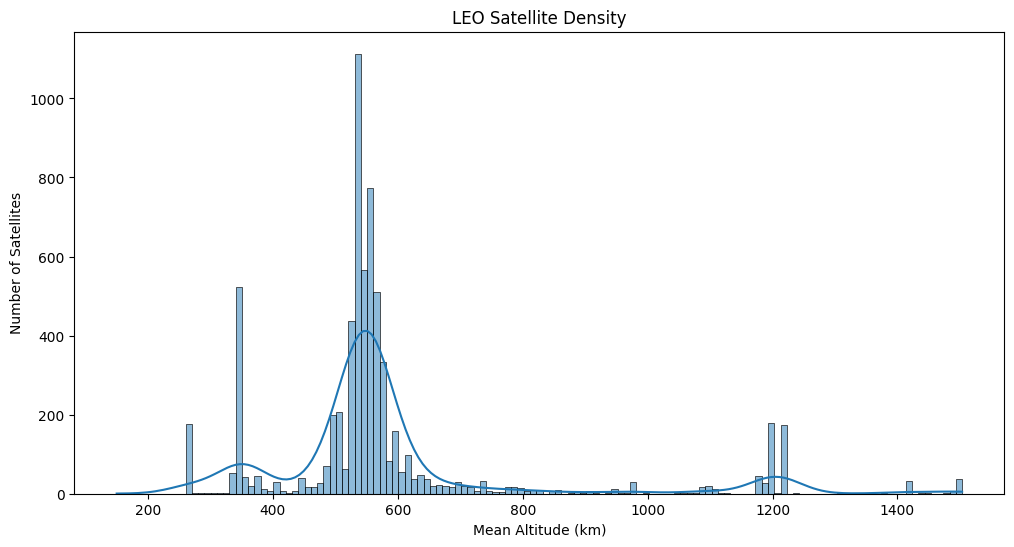

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.histplot(data=df_leo_pure, x='Mean Altitude (km)', binwidth=10, kde=True)

plt.title("LEO Satellite Density")
plt.xlabel("Mean Altitude (km)")
plt.ylabel("Number of Satellites")

plt.show()

## 6. Isolating Peak Congestion (High-Resolution View)
To investigate the primary spike observed in the global distribution, we isolate the highest density region. This allows us to pinpoint the exact orbital shell experiencing peak congestion and identify the specific operator driving the density.

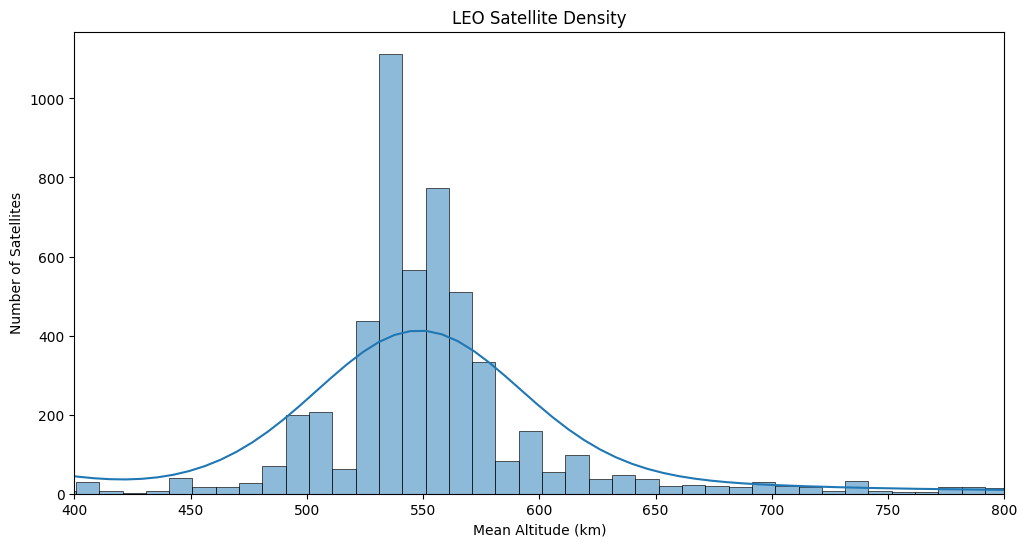

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.histplot(data=df_leo_pure, x='Mean Altitude (km)', binwidth=10, kde=True)

plt.xlim(400, 800)

plt.title("LEO Satellite Density")
plt.xlabel("Mean Altitude (km)")
plt.ylabel("Number of Satellites")

plt.show()

In [15]:
max_zone_sats = df_leo_pure[df_leo_pure['10km Band'] == peak_band].copy()

print("Top Operators operating in this altitude:")
print(max_zone_sats['Operator/Owner'].value_counts().head(3))

Top Operators operating in this altitude:
Operator/Owner
SpaceX                                       986
Chang Guang Satellite Technology Co. Ltd.     44
Planet Labs, Inc.                             32
Name: count, dtype: int64
